In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

### 1. Load dan preprocess dataset CIFAR-10


In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train / 255.0
x_test = x_test / 255.0
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### 2. Model CNN sederhana

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 3. Latih model dengan data bersih

In [ ]:
model.fit(x_train, y_train, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 50ms/step - accuracy: 0.4004 - loss: 1.6482
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.6163 - loss: 1.0919
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 41ms/step - accuracy: 0.6690 - loss: 0.9410
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 40ms/step - accuracy: 0.7096 - loss: 0.8417
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 39ms/step - accuracy: 0.7370 - loss: 0.7560
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 42ms/step - accuracy: 0.7664 - loss: 0.6696
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 64s 41ms/step - accuracy: 0.7875 - loss: 0.6089
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 40ms/step - accuracy: 0.8151 - loss: 0.5279
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 40ms/step - accuracy: 0.8336 - loss: 0.4776
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 41ms/step - accuracy: 0.8514 - loss: 0.4236


### 4. Fungsi untuk membuat adversarial example dengan FGSM

In [ ]:
def create_adversarial_example(model, image, label, epsilon=0.1):
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    label = tf.convert_to_tensor(label, dtype=tf.int64)
    with tf.GradientTape() as tape:
        tape.watch(image)
        prediction = model(image)
        loss = tf.keras.losses.sparse_categorical_crossentropy(label, prediction)
    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)  #tanda gradien
    adversarial_image = image + epsilon * signed_grad  # +noise
    adversarial_image = tf.clip_by_value(adversarial_image, 0, 1)
    return adversarial_image

### 5. Simulasi serangan pada gambar tank (kelas 9 di CIFAR-10)

In [ ]:
tank_indices = np.where(y_test.flatten() == 9)[0]
sample_index = tank_indices[0]
original_image = x_test[sample_index:sample_index+1]
original_label = y_test[sample_index:sample_index+1]
adversarial_image = create_adversarial_example(model, original_image, original_label)

### 6. Prediksi pada gambar asli dan adversarial

In [ ]:
original_pred = np.argmax(model.predict(original_image), axis=1)
adversarial_pred = np.argmax(model.predict(adversarial_image), axis=1)
print(f"Prediksi gambar asli: {class_names[original_pred[0]]}")
print(f"Prediksi gambar adversarial: {class_names[adversarial_pred[0]]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Prediksi gambar asli: truck
Prediksi gambar adversarial: automobile


### 7. Visualisasi gambar asli vs adversarial

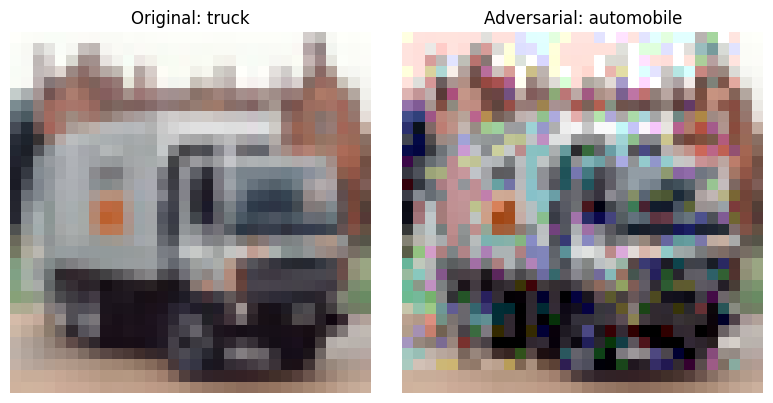

In [ ]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(original_image.reshape(32, 32, 3))
plt.title(f"Original: {class_names[original_pred[0]]}")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(adversarial_image.numpy().reshape(32, 32, 3))
plt.title(f"Adversarial: {class_names[adversarial_pred[0]]}")
plt.axis('off')
plt.tight_layout()
plt.show()